In [12]:
import RandomTilingsV1 as RT1
import RandomTilingsV2 as RT2

import numpy as np
import matplotlib.pyplot as plt
from time import time
from tqdm import trange

# Timing of Reduction

In [23]:
weight_aztec = RT1.weight_aztec.weight_aztec
reduceV1 = RT1.algorithm_reduction_weight.algorithm_reduction_weight
shuffleV1 = RT1.shuffling.shuffling

In [37]:
red_V1   = []
red_V2   = []
red_V2m  = []

shuf_V1  = []
shuf_V2  = []
shuf_V2m = []

w = np.array([[1.]])

max_n = 101
reps  = 20
for n in trange(1,max_n):
    t1 = time()
    for _ in range(reps):
        W  = weight_aztec(n,w)
        C = reduceV1(W)
    red_V1 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        M = shuffleV1(C)
    shuf_V1 += [(time()-t1)/reps]


    t1 = time()
    for _ in range(reps):
        A = RT2.Aztec(n,w)
    red_V2 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        A.shuffle()
    shuf_V2 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        A = RT2.Aztec(n,w,memory_mode=True)
    red_V2m += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        A.shuffle()
    shuf_V2m += [(time()-t1)/reps]

100%|██████████| 100/100 [02:06<00:00,  1.26s/it]


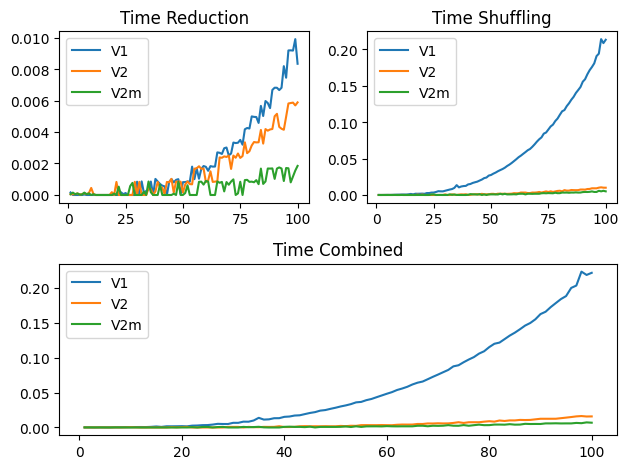

In [38]:
red_V1  = np.array(red_V1)
red_V2  = np.array(red_V2)
red_V2m = np.array(red_V2m)

shuf_V1  = np.array(shuf_V1)
shuf_V2  = np.array(shuf_V2)
shuf_V2m = np.array(shuf_V2m)

import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.linspace(0, 10, 100)

# Create figure
fig = plt.figure()

# Define grid: 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# First row (two separate plots)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Second row (one plot spanning both columns)
ax3 = fig.add_subplot(gs[1, :])

# Plot something
ax1.set_title('Time Reduction')
ax1.plot(range(1,len(red_V1)+1),red_V1,label = 'V1')
ax1.plot(range(1,len(red_V2)+1),red_V2,label = 'V2')
ax1.plot(range(1,len(red_V2m)+1),red_V2m,label = 'V2m')
ax1.legend()

ax2.set_title('Time Shuffling')
ax2.plot(range(1,len(red_V1)+1),shuf_V1,label = 'V1')
ax2.plot(range(1,len(red_V2)+1),shuf_V2,label = 'V2')
ax2.plot(range(1,len(red_V2m)+1),shuf_V2m,label = 'V2m')
ax2.legend()


ax3.set_title('Time Combined')
ax3.plot(range(1,len(red_V1)+1),shuf_V1+red_V1,label = 'V1')
ax3.plot(range(1,len(red_V2)+1),shuf_V2+red_V2,label = 'V2')
ax3.plot(range(1,len(red_V2m)+1),shuf_V2m+red_V2m,label = 'V2m')
ax3.legend()

plt.tight_layout()
plt.show()

